# Figure 3A: ROI

Working with classes from `region_plotting.py`

In [ ]:
import matplotlib as mpl
import pandas as pd

from modules.region_plotting import RegionPlotter
from modules.germany import germany

In [2]:
mpl.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42,
                     'xtick.labelsize': 12,
                     'ytick.labelsize': 12,
                     'axes.labelsize': 12,
                     'font.size': 12
                    })

## Set parameters

In [3]:
region = ('chr2', 29_200_000, 31_200_000) # nice

# chip-seq
binsize = 2000
chip_vmin = None
chip_vmax = None
sor_wt = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/WT_G2/Sororin_WT_G2.chip.bw'
sor_dctcf = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/dCTCF_G2/Sororin_dCTCF_G2.chip.bw'

# boundaries
new_level_colors = {'high': 'k', 'med': '.5', 'low': 'w'}
edge_colors = {'high': None, 'med': None, 'low': 'k'}
hue = 'levelGroup'
boundaries_df = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')

## Figure 3A - Plot ChIP-Seq

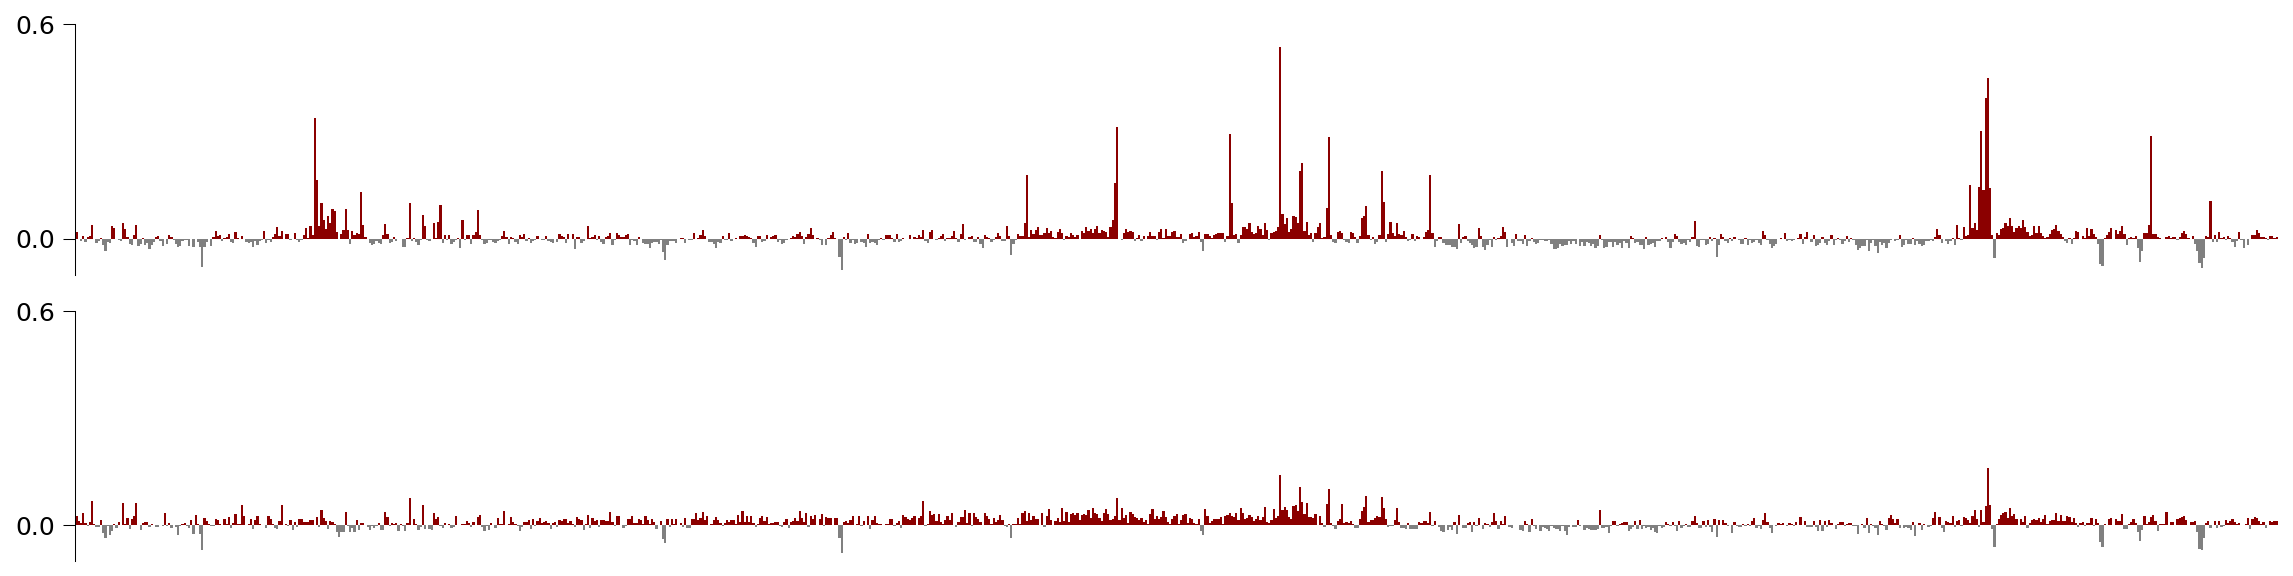

In [5]:
fig_plotter = RegionPlotter(*region)

fig_plotter.add_fill(sor_wt, binsize, -0.1, 0.6, 'grey', 'darkred', height=1, mean_subtract=True)
fig_plotter.add_fill(sor_dctcf, binsize, -0.1, 0.6, 'grey', 'darkred', height=1, mean_subtract=True)

fig, axes = fig_plotter.plot(figsize=(16, 4), dpi=150, tick_all=False, tick_step=1_000_000)

for i in range(2):
    axes[i,0].xaxis.set_visible(False) # Remove x axis
    axes[i,0].spines['bottom'].set_visible(False) # Remove the horizontal line
    axes[i,0].set_yticks([0, 0.6])
    axes[i,0].tick_params(axis='y', length=6, width=0.5)
    for spine in axes[i, 0].spines.values():
        spine.set_linewidth(0.5)

fig.tight_layout()

## Figure 3A - Plot Boundaries

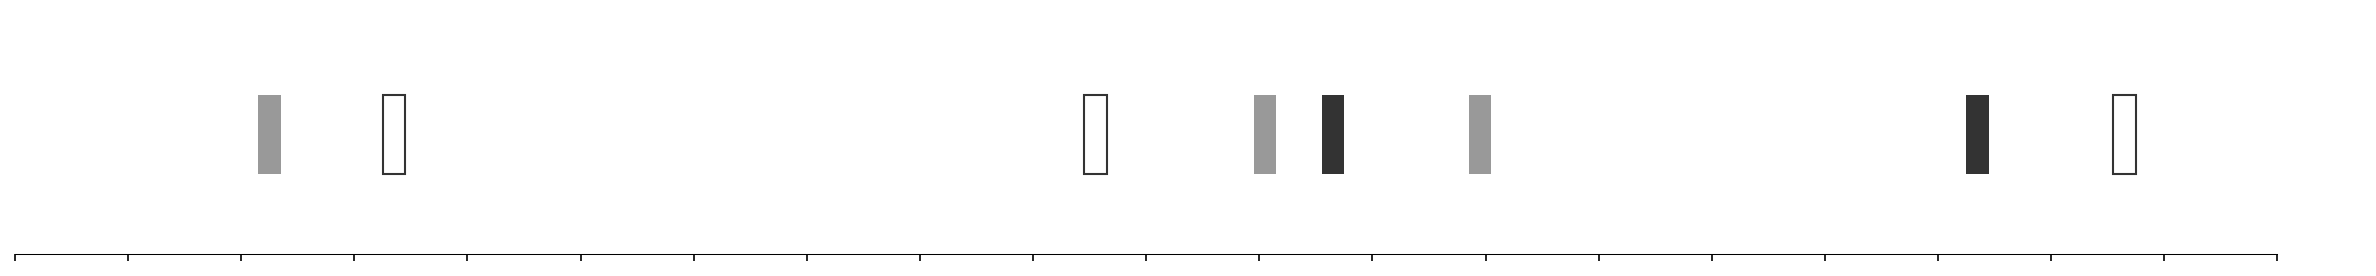

In [4]:
fig_plotter = RegionPlotter(*region)

new_level_colors = {'high': 'k', 'med': '.5', 'low': 'w'}
edge_colors = {'high': None, 'med': None, 'low': 'k'}
fig_plotter.add_df_multi(boundaries_df, hue, new_level_colors, edgecolors=edge_colors, stratify=False, pad=5_000, height=1)

fig, axes = fig_plotter.plot(figsize=(16, 2), dpi=150, tick_all=False, tick_step=100_000)
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_xticklabels([])  # Remove x-axis tick labels
    ax.spines['bottom'].set_linewidth(0.5)
    legend = ax.get_legend()
    if legend:
        legend.remove()

fig.tight_layout()

# Suppl. Figure 3J

## Set parameters

In [6]:
sfig3_region = ('chr3', 97_800_000, 99_800_000)

# hi-c
resolution = 10_000
max_separation = 1_000_000
hic_vmin = 3e-4
hic_vmax = 3e-1

wt_path = '/groups/gerlich/experiments/Experiments_006500/006575/coolers_repo/WT_G2/WT_G2.all.mcool'
dctcf_path = '/groups/gerlich/experiments/Experiments_006500/006575/coolers_repo/dCTCF_G2/dCTCF_G2.all.mcool'

## Plot Hi-C

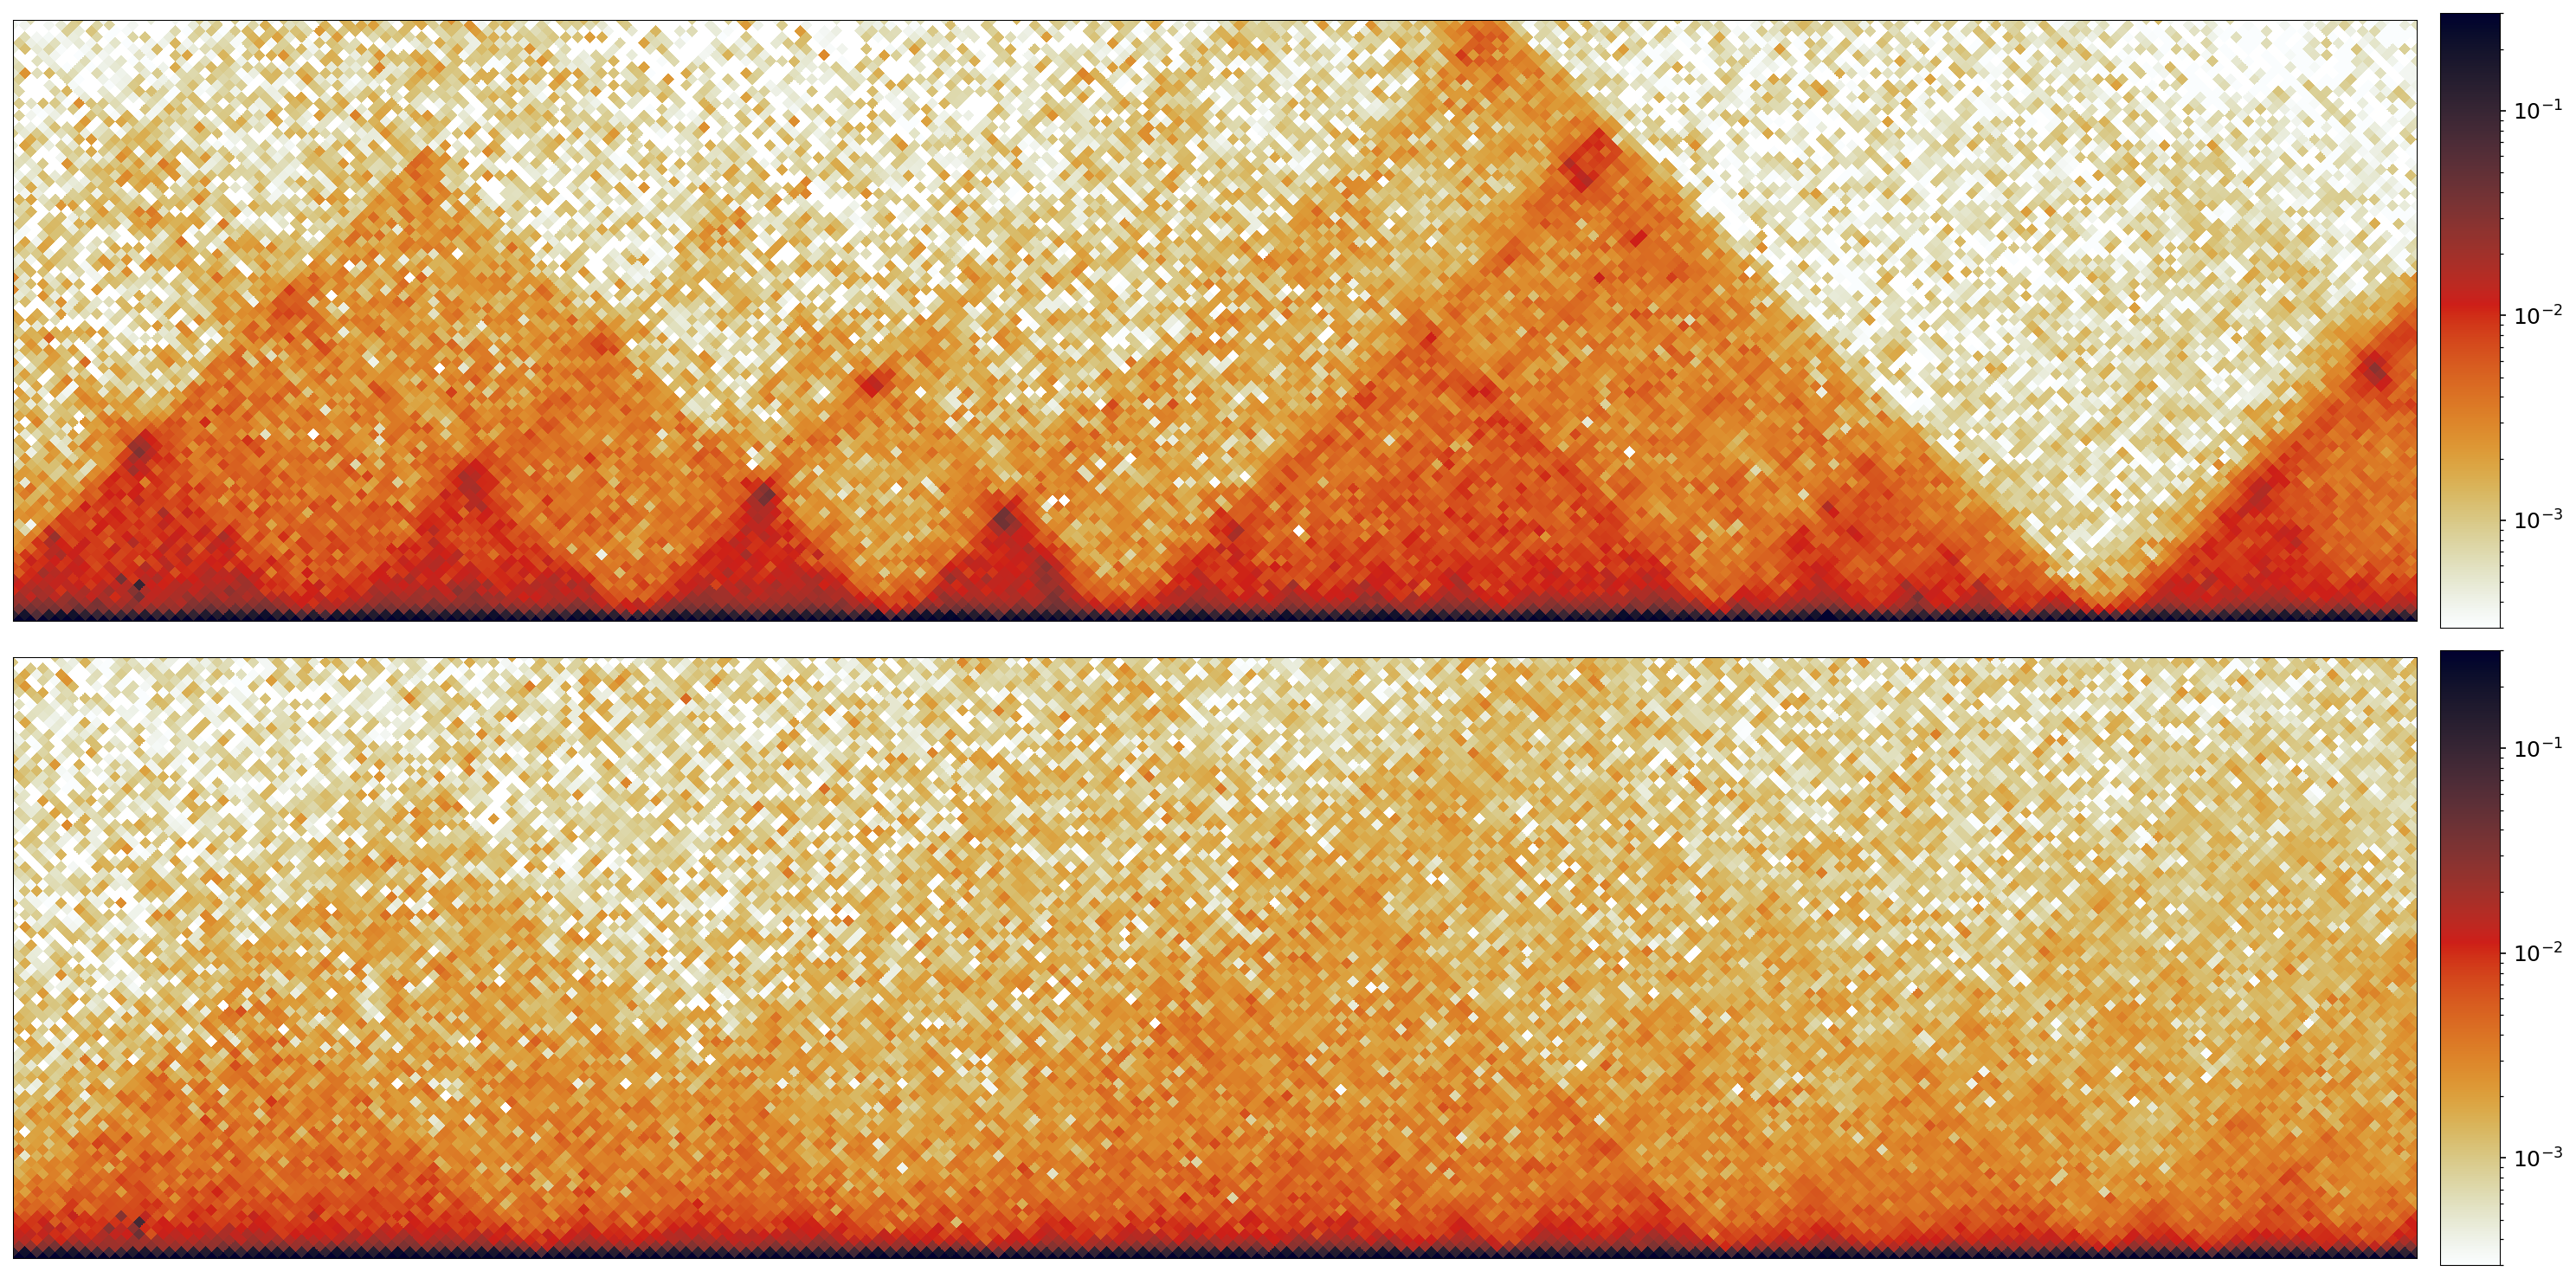

In [11]:
sfig3_plotter = RegionPlotter(*sfig3_region)
sfig3_plotter.add_hic(wt_path, resolution, hic_vmin, hic_vmax, max_separation, germany, height=1)
sfig3_plotter.add_hic(dctcf_path, resolution, hic_vmin, hic_vmax, max_separation, germany, height=1)

fig, axes = sfig3_plotter.plot(figsize=(20, 10), dpi=150, tick_all=False, tick_step=100_000)
for i in range(2):
    axes[i,0].set_yticks([]) # change yticks on the Hi-C track
    axes[i,0].set_yticklabels([]) # rename yticks on the Hi-C track
    axes[i,0].set_xticks([])
    axes[i,0].set_xticklabels([])

for ax in axes.flat:
    ax.set_xlabel('')  # Remove x-axis label

    # Set border linewidth and make all spines visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)  # Adjust linewidth as needed
        spine.set_visible(True)  # Ensure all borders are visible

fig.tight_layout()